# Bagging, Boosting and Stacked Ensemble Models.
## Importing Dependencies

In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sys
from pathlib import Path

# Add the project root (ml_laboratory) to Python's search path
sys.path.append(str(Path().resolve().parent))
from utils import (
    eda_tabular
)
print("Imported")

Imported successfully
Imported


## 1. EDA Analysis

In [2]:
df = pd.read_csv("../datasets/breast_cancer/wdbc.data",header=None)
features = [
    "radius", "texture", "perimeter", 
    "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"
]


In [3]:
df = df.drop(0, axis = 1)
column_names = ["diagnosis"]
for suffix in ["_mean", "_se", "_worst"]:
    column_names.extend([f"{feat}{suffix}" for feat in features])

df.columns = column_names
display(df.head())


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Shape: (569, 31)

Column types:
 diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst       

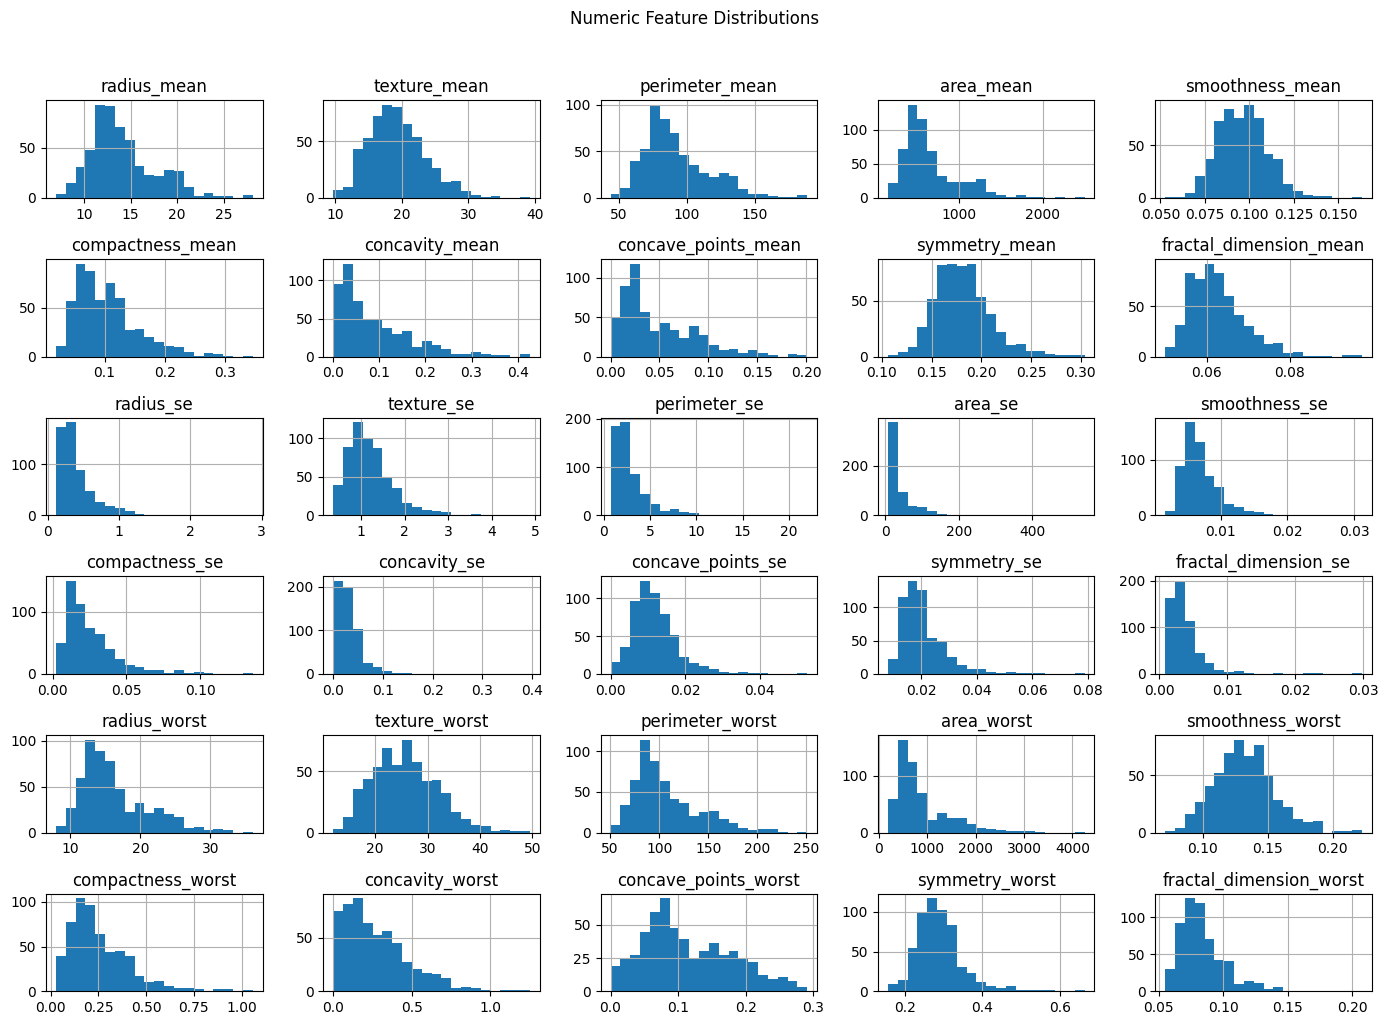

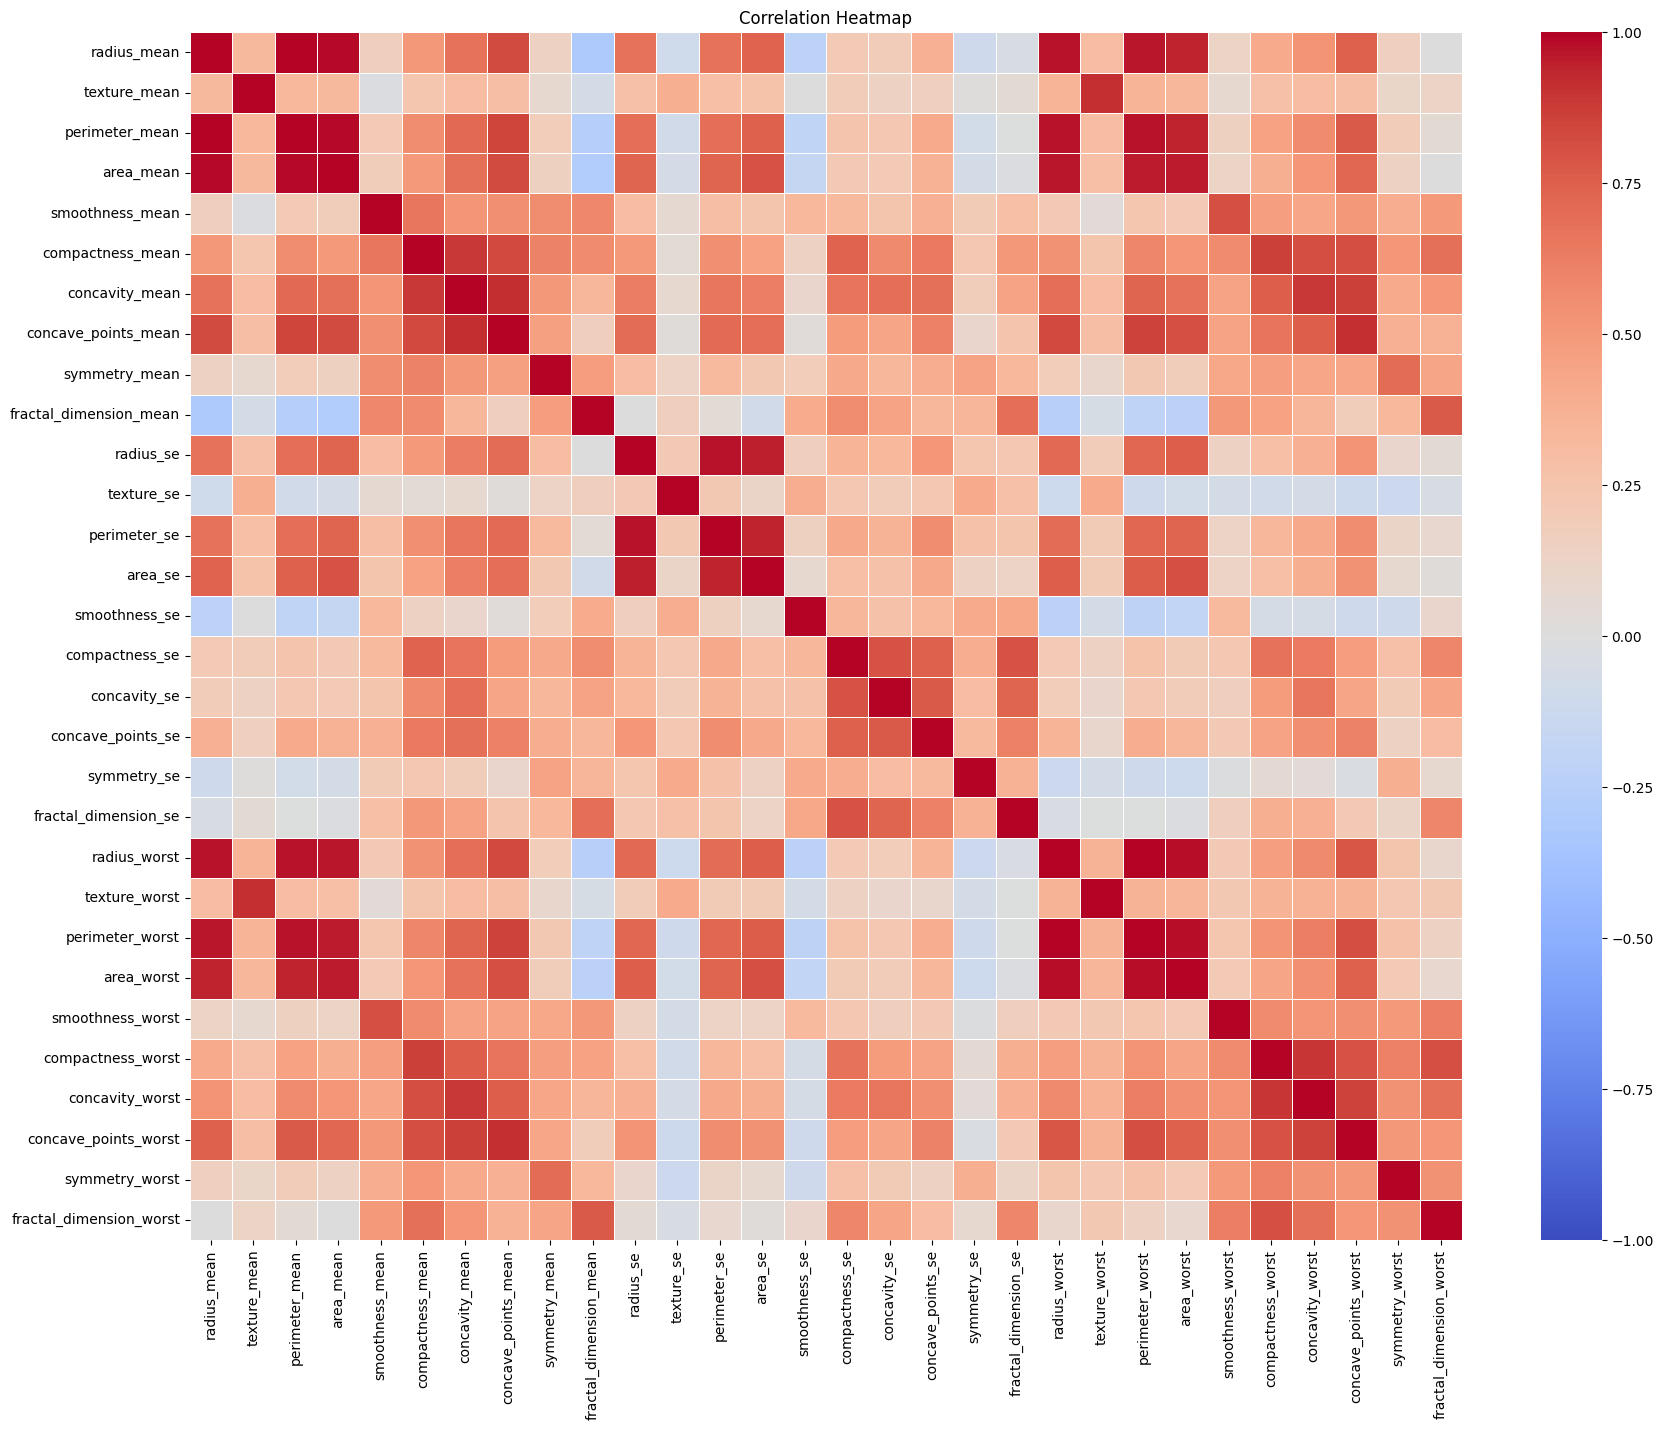


Plotting Categorical Distributions...


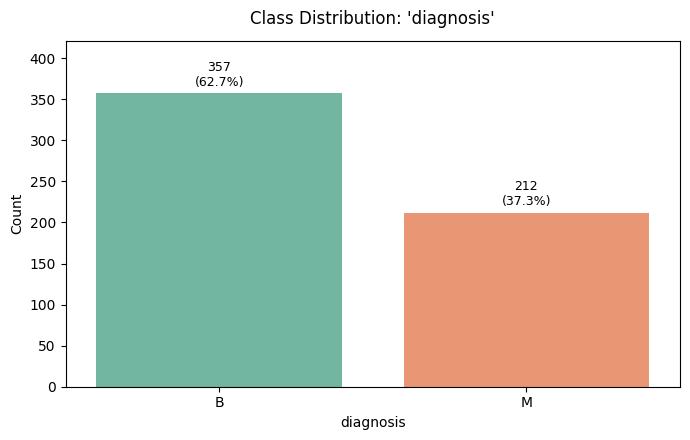

(Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
        'smoothness_mean', 'compactness_mean', 'concavity_mean',
        'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
        'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
        'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
        'fractal_dimension_se', 'radius_worst', 'texture_worst',
        'perimeter_worst', 'area_worst', 'smoothness_worst',
        'compactness_worst', 'concavity_worst', 'concave_points_worst',
        'symmetry_worst', 'fractal_dimension_worst'],
       dtype='str'),
 Index(['diagnosis'], dtype='str'))

In [4]:
eda_tabular(df)

## 2. Train Test Split

In [5]:
from sklearn.model_selection import train_test_split
X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

print(f"X Train shape - {X_train.shape} & X Test shape - {X_test.shape}")
print(f"y Train shape - {y_train.shape} & y Test shape - {y_test.shape}")

X Train shape - (455, 30) & X Test shape - (114, 30)
y Train shape - (455,) & y Test shape - (114,)


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred =model.predict(X_test)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:\n {classification_report(y_test, y_pred)}")


Test Accuracy: 0.947

Classification Report:
               precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## 3. Bagging
Bagging creates `n_estimators` no. of Decision Trees. Each gets portion of training data according to `max_samples` by Bootstrap Sampling i.e. *Samples are drawn with Replacement* and uses fraction of features according to `max_features`.

| Hyper parameter | Controls |
|----------------|--------|
| `n_estimators` | Number of Trees |
| `max_samples`  | Fraction of training samples per tree |
| `max_features` | Fraction of Features used by each tree|

In [7]:
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(
    estimator = DecisionTreeClassifier(random_state = 42),
    n_estimators = 100,
    max_samples = 0.8,
    max_features = 1.0,
    random_state = 42
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

In [8]:
print("Bagging")
print("Accuracy:", accuracy_score(y_test,y_pred_bag))
print("Classification by Bagging Report:\n", classification_report(y_test,y_pred_bag))

Bagging
Accuracy: 0.956140350877193
Classification by Bagging Report:
               precision    recall  f1-score   support

           B       0.96      0.97      0.97        71
           M       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 3.1. Bagging Hyperparameter Tuning
Using `GridSearchCV` to choose combinations of:
- `n_estimators`
- `max_samples`
- `max_features`

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100],
    "max_samples": [0.8, 1.0],
    "max_features": [0.8, 1.0]
}

f1_m = make_scorer(f1_score, pos_label="M")

grid_bag = GridSearchCV(
    bagging,
    param_grid,
    cv=5,
    scoring={
        "f1": f1_m,
        "accuracy": "accuracy"
    },
    refit="f1",
    n_jobs=-1
)

grid_bag.fit(X_train, y_train)

print("Best Parameters:", grid_bag.best_params_)
print("Best CV F1:", grid_bag.best_score_)

best_index = grid_bag.best_index_

print("Best CV Accuracy:", grid_bag.cv_results_["mean_test_accuracy"][best_index])
print("Best CV F1:", grid_bag.cv_results_["mean_test_f1"][best_index])

Best Parameters: {'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 100}
Best CV F1: 0.9362651808975337
Best CV Accuracy: 0.9538461538461538
Best CV F1: 0.9362651808975337


In [10]:
bagging_cv_df = pd.DataFrame({
    "n_estimators": grid_bag.cv_results_["param_n_estimators"],
    "max_samples": grid_bag.cv_results_["param_max_samples"],
    "max_features": grid_bag.cv_results_["param_max_features"],
    "Avg CV Accuracy (%)": grid_bag.cv_results_["mean_test_accuracy"] * 100,
    "Avg CV F1 Score": grid_bag.cv_results_["mean_test_f1"]
})

bagging_cv_df = bagging_cv_df.sort_values(
    by="Avg CV F1 Score",
    ascending=False
).reset_index(drop=True)
display(bagging_cv_df)

,n_estimators,max_samples,max_features,Avg CV Accuracy (%),Avg CV F1 Score
0,100,0.8,0.8,95.384615,0.936265
1,50,0.8,0.8,95.384615,0.936168
2,100,1.0,0.8,95.384615,0.935886
3,50,1.0,0.8,95.164835,0.933461
4,50,0.8,1.0,94.945055,0.930664
5,100,0.8,1.0,94.725275,0.927416
6,50,1.0,1.0,94.505495,0.923946
7,100,1.0,1.0,94.285714,0.921242


## 4. Boosting
### 4.1. AdaBoost

In [11]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score

ada = AdaBoostClassifier(
    n_estimators = 100,
    learning_rate = .5,
    random_state = 42
)
ada.fit(X_train,y_train)
y_pred_ada = ada.predict(X_test)

f1_m = make_scorer(f1_score, pos_label="M")

ada_cv = cross_validate(
    ada,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "f1": f1_m
    },
    n_jobs=-1
)

ada_cv_accuracy = ada_cv["test_accuracy"].mean() * 100
ada_cv_f1 = ada_cv["test_f1"].mean()

print("AdaBoost")
print("Avg CV Accuracy (%):", ada_cv_accuracy)
print("Avg CV F1 Score:", ada_cv_f1)

AdaBoost
Avg CV Accuracy (%): 97.14285714285715
Avg CV F1 Score: 0.9601559303051841


In [12]:
print("AdaBoost\n",classification_report(y_test,y_pred_ada))

AdaBoost
               precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### 4.2 Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate=.1,
    max_depth = 3,
    random_state=42
)
gb.fit(X_train,y_train)
y_pred_gb = gb.predict(X_test)

gb_cv = cross_validate(
    gb,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "f1": f1_m
    },
    n_jobs=-1
)

gb_cv_accuracy = gb_cv["test_accuracy"].mean() * 100
gb_cv_f1 = gb_cv["test_f1"].mean()

print("Gradient Boosting")
print("Avg CV Accuracy (%):", gb_cv_accuracy)
print("Avg CV F1 Score:", gb_cv_f1)

Gradient Boosting
Avg CV Accuracy (%): 95.16483516483515
Avg CV F1 Score: 0.9336573720397251


In [14]:
print("Gradient Boosting\n",classification_report(y_test,y_pred_gb))

Gradient Boosting
               precision    recall  f1-score   support

           B       0.96      0.97      0.97        71
           M       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 5. Stacking
Using **Logistic Regression** as *Meta Learner*
### 5.1 Support Vector Machine (SVM):

In [15]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

base_models = [
    ("svm", SVC(probability = True, random_state = 42)),
    ("nb", GaussianNB()),
    ("dt", DecisionTreeClassifier(random_state=42))
]
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv =5 
)
stacking.fit(X_train,y_train)
y_pred_stack = stacking.predict(X_test)


stack_cv = cross_validate(
    stacking,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "f1": f1_m
    },
    n_jobs=-1
)

stack_cv_accuracy = stack_cv["test_accuracy"].mean() * 100
stack_cv_f1 = stack_cv["test_f1"].mean()

print("Stacking")
print("Avg CV Accuracy (%):", stack_cv_accuracy)
print("Avg CV F1 Score:", stack_cv_f1)

Stacking
Avg CV Accuracy (%): 94.72527472527472
Avg CV F1 Score: 0.9257109134826527


In [16]:
print("Stacking\n",classification_report(y_test, y_pred_stack))

Stacking
               precision    recall  f1-score   support

           B       0.96      1.00      0.98        71
           M       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Hyperparmater Selection

In [17]:
boosting_cv_results = pd.DataFrame([
    {
        "Model": "AdaBoost",
        "n_estimators": 100,
        "learning_rate": 0.5,
        "max_depth": "-",
        "Avg CV Accuracy (%)": ada_cv_accuracy,
        "Avg CV F1 Score": ada_cv_f1
    },
    {
        "Model": "Gradient Boosting",
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 3,
        "Avg CV Accuracy (%)": gb_cv_accuracy,
        "Avg CV F1 Score": gb_cv_f1
    }
])

display(boosting_cv_results)

,Model,n_estimators,learning_rate,max_depth,Avg CV Accuracy (%),Avg CV F1 Score
0,AdaBoost,100,0.5,-,97.142857,0.960156
1,Gradient Boosting,100,0.1,3,95.164835,0.933657


In [25]:
stacking_cv_results = pd.DataFrame([
    {
        "Base Models": "SVM + GaussianNB + Decision Tree",
        "Meta Learner": "Logistic Regression",
        "Avg CV Accuracy (%)": stack_cv_accuracy,
        "Avg CV F1 Score": stack_cv_f1
    }
])

display(stacking_cv_results)

,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM + GaussianNB + Decision Tree,Logistic Regression,94.725275,0.925711


## 6. Comparison of ensemble models

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
grid_bag.fit(X_train,y_train)
models = {
    "Decision Tree": model,
    "Bagging": grid_bag.best_estimator_,
    "AdaBoost": ada,
    "Gradient Boosting": gb,
    "Stacking":stacking
}
result = []
for name, model in models.items():
    y_pred = model.predict(X_test)

    result.append({
        "Model":name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label = "M"),
        "Recall": recall_score(y_test, y_pred, pos_label = "M"),
        "F1 Score": f1_score(y_test, y_pred, pos_label = "M")
    })

result_df = pd.DataFrame(result)
display(result_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.947368,0.930233,0.930233,0.930233
1,Bagging,0.964912,0.975610,0.930233,0.952381
2,AdaBoost,0.964912,0.975610,0.930233,0.952381
3,Gradient Boosting,0.956140,0.952381,0.930233,0.941176
4,Stacking,0.973684,1.000000,0.930233,0.963855


## 7. Confusion Matrix

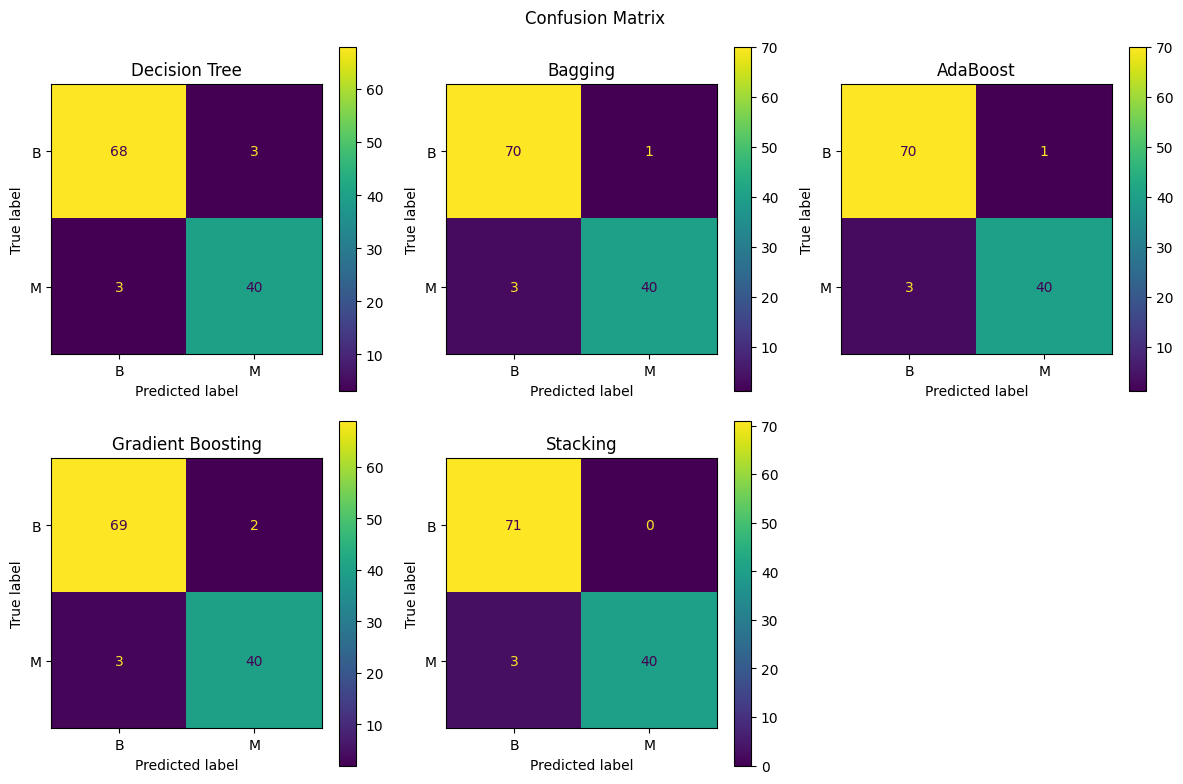

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2,3,figsize = (12,8))
axes = axes.ravel()
for i, (name,model) in enumerate(models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap = 'viridis',
        ax=axes[i]
    )
    axes[i].set_title(f"{name}")
# Remove empty 6th subplot
fig.delaxes(axes[-1])

plt.suptitle("Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. ROC Curve and AUC

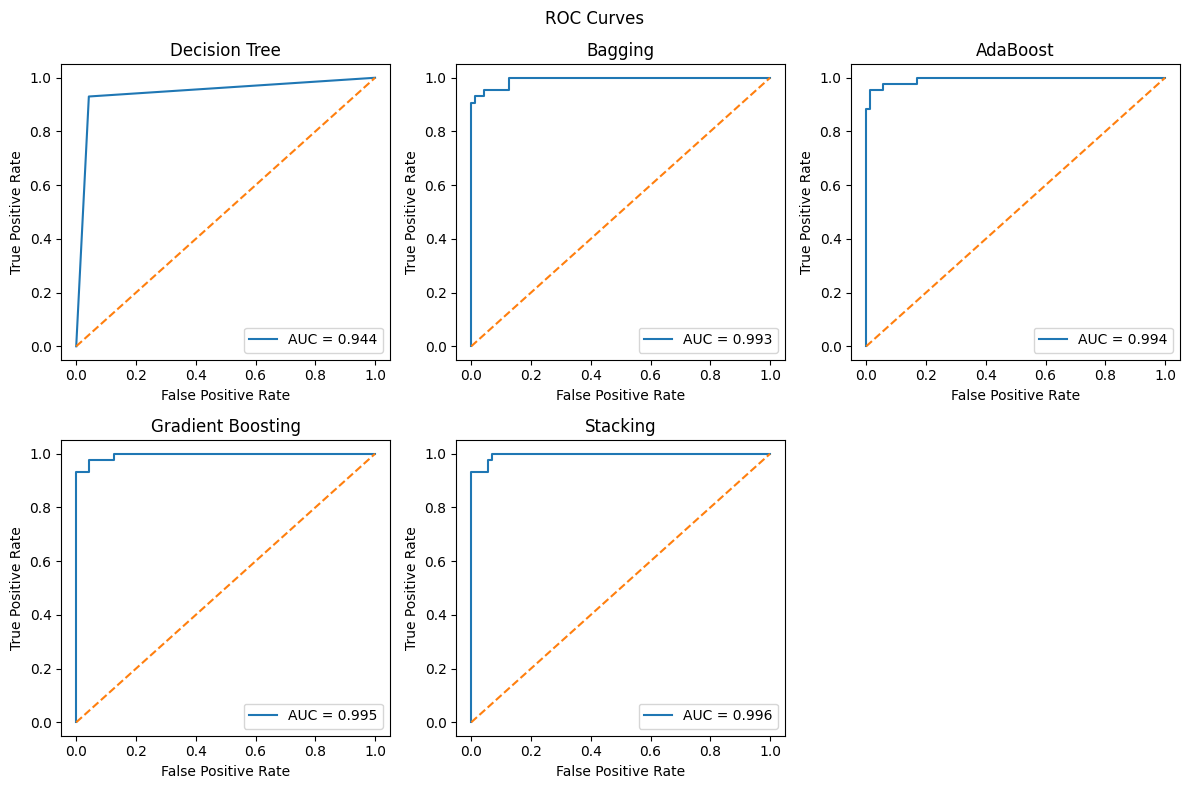

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label="M")
    auc = roc_auc_score(y_test, y_prob)

    axes[i].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    axes[i].plot([0, 1], [0, 1], linestyle="--")
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].set_title(name)
    axes[i].legend()

# Remove empty 6th subplot
fig.delaxes(axes[-1])

plt.suptitle("ROC Curves")
plt.tight_layout()
plt.show()

## 9. Performance Comparison

## 10. Bias-variance analysis

In [21]:
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

bias_variance = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    bias_variance.append({
        "Model": name,
        "Training Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap": train_acc - test_acc
    })

bv_df = pd.DataFrame(bias_variance)
print(bv_df)

               Model  Training Accuracy  Test Accuracy       Gap
0      Decision Tree           1.000000       0.947368  0.052632
1            Bagging           0.997802       0.964912  0.032890
2           AdaBoost           1.000000       0.964912  0.035088
3  Gradient Boosting           1.000000       0.956140  0.043860
4           Stacking           0.973626       0.973684 -0.000058


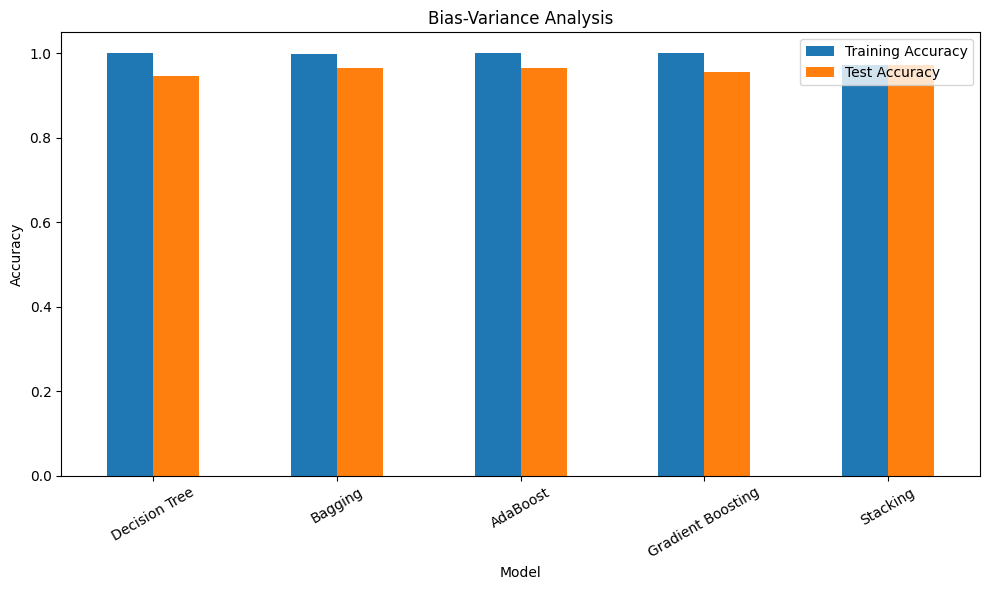

In [22]:
ax = bv_df.set_index("Model")[["Training Accuracy", "Test Accuracy"]].plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel("Accuracy")
ax.set_title("Bias-Variance Analysis")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

print(cv_df)

               Model  Mean Accuracy       Std
0      Decision Tree       0.916484  0.016447
1            Bagging       0.953846  0.014579
2           AdaBoost       0.971429  0.017855
3  Gradient Boosting       0.951648  0.016447
4           Stacking       0.947253  0.016150


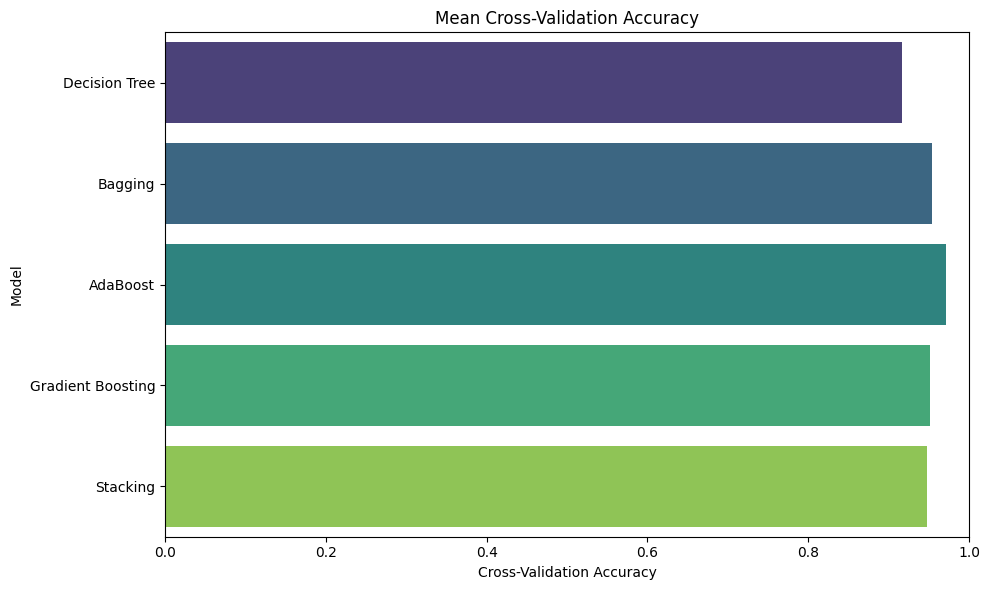

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_df,
    y="Model",
    x="Mean Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.xlabel("Cross-Validation Accuracy")
plt.ylabel("Model")
plt.title("Mean Cross-Validation Accuracy")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()